<a href="https://colab.research.google.com/github/suyogy1-bot/Machine_Learning/blob/main/Car_Price_Prediction/Linear_Ridge_%26_Lasso_Regression_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚗 Car Price Prediction — Linear, Ridge & Lasso Regression

**Dataset:** Used Car Sales Data  
**Goal:** Predict the price of a used car based on its features  
**Models Used:** Linear Regression → Ridge → Lasso

---

> 💡 **What will you learn?**
> - How to clean a real-world messy dataset
> - Why we use log transformation on skewed data
> - How Linear, Ridge, and Lasso Regression work
> - How to compare models and pick the best one

## Step 1 — Import Libraries

**Why?**  
Before doing anything, we load the tools we need.
- `pandas` → to load and work with data (like Excel in Python)
- `numpy` → for math operations
- `matplotlib` & `seaborn` → to make graphs
- `sklearn` → machine learning models

In [173]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2 — Load the Dataset

**Why?**  
We load our CSV file into a DataFrame — think of it as opening an Excel sheet in Python.

After loading, we always check:
- How many rows and columns are there?
- What does the data look like?

In [174]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "1.04. Real-life example.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "smritisingh1997/car-salescsv",
  file_path,

)

print("First 5 records:", df.head())

/tmp/ipykernel_2108/167104996.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'car-salescsv' dataset.
First 5 records:            Brand    Price       Body  Mileage  EngineV Engine Type  \
0            BMW   4200.0      sedan      277      2.0      Petrol   
1  Mercedes-Benz   7900.0        van      427      2.9      Diesel   
2  Mercedes-Benz  13300.0      sedan      358      5.0         Gas   
3           Audi  23000.0  crossover      240      4.2      Petrol   
4         Toyota  18300.0  crossover      120      2.0      Petrol   

  Registration  Year         Model  
0          yes  1991           320  
1          yes  1999  Sprinter 212  
2          yes  2003         S 500  
3          yes  2007            Q7  
4          yes  2011         Rav 4  


## Step 3 — Explore the Data (EDA)

**Why?**  
Before building any model, we need to *understand* our data.

We check:
- Data types of each column
- Basic statistics (min, max, average)
- Missing values — are there any empty cells?

> ⚠️ **Real-world data is almost never clean. Always explore first!**

In [175]:
df.dtypes
df.describe()
df.isnull().sum()


,0
Brand,0
Price,172
Body,0
Mileage,0
EngineV,150
Engine Type,0
Registration,0
Year,0
Model,0


## Step 4 — Handle Missing Values

**Why?**  
Machine learning models cannot work with empty (NaN) values.  
We have missing values in `Price` and `EngineV`.

**Solution:** Drop rows where Price or EngineV is missing.

> 💡 `dropna()` removes rows that have missing values in the specified columns.

In [176]:
df = df.dropna(subset =['Price', 'EngineV'])
df.isnull().sum()


,0
Brand,0
Price,0
Body,0
Mileage,0
EngineV,0
Engine Type,0
Registration,0
Year,0
Model,0


## Step 5 — Remove Outliers from EngineV

**Why?**  
Look at the max value of `EngineV` — it shows **99.99!**  
No car has a 99-litre engine. These are data entry mistakes.

Outliers confuse the model and give wrong predictions.  
We keep only realistic engine sizes (≤ 10 litres).

> 💡 Always ask: *"Does this value make real-world sense?"*

<Axes: >

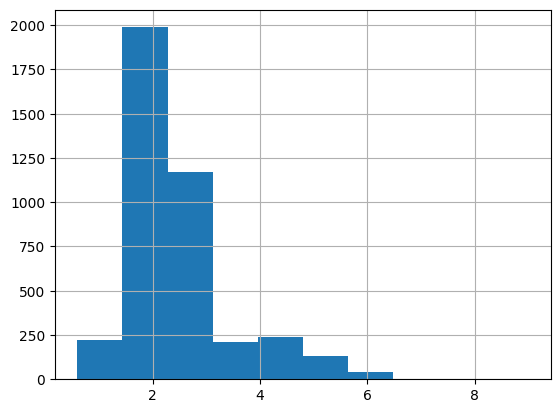

In [177]:
df = df[df['EngineV'] <= 10]
df['EngineV'].hist()

## Step 6 — Check Distribution of Target Variable (Price)

**Why?**  
Linear Regression works best when the target variable is **normally distributed** (bell-shaped).  

Let's plot `Price` and see its shape.

## Step 7 — Apply Log Transformation

**Why?**  
The raw `Price` is heavily right-skewed (skewness = 4.45).  
After `log(Price)`, skewness drops to ~0.24 — almost normal!

This helps our model make much better predictions.

> ⚠️ We also drop the `Model` column — it has 312 unique values (too many for simple encoding).

<Axes: >

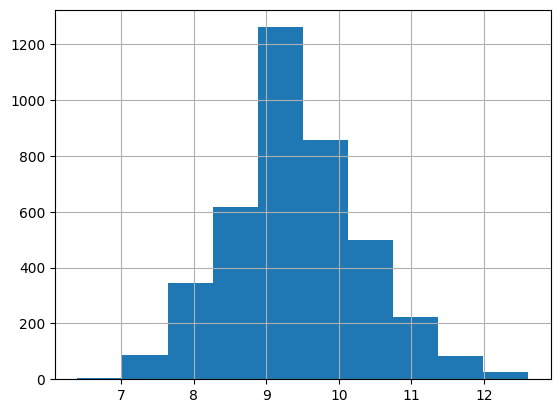

In [178]:
df['Log_Price'] = np.log(df['Price'])
df = df.drop(columns=['Model'])
df['Log_Price'].hist()

## Step 8 — Encode Categorical Columns

**Why?**  
Machine learning models only understand **numbers**, not text like 'BMW' or 'Diesel'.

We use **Label Encoding** to convert text categories into numbers.

| Text | Encoded |
|------|---------|
| Audi | 0 |
| BMW  | 1 |
| Toyota | 2 |

> 💡 `LabelEncoder` assigns a unique number to each category automatically.

In [179]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
cat_col = df.select_dtypes(include=['object']).columns
df[cat_col] = df[cat_col].apply(encoder.fit_transform)
df.head()

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Log_Price
0,1,4200.0,3,277,2.0,3,1,1991,8.342840
1,2,7900.0,5,427,2.9,0,1,1999,8.974618
2,2,13300.0,3,358,5.0,1,1,2003,9.495519
3,0,23000.0,0,240,4.2,3,1,2007,10.043249
4,5,18300.0,0,120,2.0,3,1,2011,9.814656


## Step 9 — Correlation Heatmap

**Why?**  
A heatmap shows how strongly each feature is related to `log_price`.

- Value close to **+1** → strong positive relationship (feature goes up, price goes up)
- Value close to **-1** → strong negative relationship (feature goes up, price goes down)
- Value close to **0** → weak/no relationship

> 💡 This helps us understand which features are most important for prediction.

<Axes: >

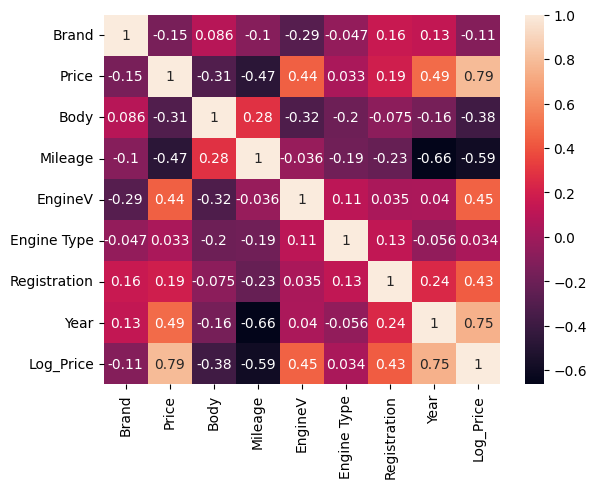

In [180]:
sns.heatmap(df.corr(), annot=True)

## Step 10 — Split Data into Train and Test Sets

**Why?**  
We train the model on one part of the data, and test it on a *different* part it has never seen.

This tells us how well the model performs on **new, unseen data** — which is the real goal!

| Split | Purpose |
|-------|---------|
| 80% Train | Model learns from this |
| 20% Test  | We evaluate model here |

> 💡 `random_state=42` ensures same split every time you run the code.

In [181]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Log_Price', 'Price'])
y = df['Log_Price']

In [182]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [183]:
X_train.head()

,Brand,Body,Mileage,EngineV,Engine Type,Registration,Year
2391,3,5,350,1.8,1,1,1992
2709,1,0,73,3.0,0,1,2013
1914,2,0,82,5.5,3,1,2014
457,1,3,328,2.5,0,0,1996
3264,2,3,230,5.0,3,1,2002


In [184]:
X_train.shape

(3204, 7)

In [185]:
X_test.shape

(801, 7)

In [186]:
y_train.shape

(3204,)

In [187]:
y_test.shape

(801,)

## Step 11 — Linear Regression

**Why start here?**  
Linear Regression is the simplest and most foundational regression model.

It finds the best straight line (or plane in multiple dimensions) that fits the data.

**Formula:**  
`Price = b0 + b1×Year + b2×Mileage + b3×EngineV + ...`

In [188]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [189]:
model.score(X_train, y_train)

0.8378818923198132

In [190]:
y_predict = model.predict(X_test)

In [191]:
y_predict[:10]

array([ 9.09309163,  9.50170502,  9.42385017,  7.58575709,  9.50805021,
       10.25916643,  8.9499889 ,  9.54100524,  8.92980826,  7.40555721])

In [192]:
compare = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_predict
})
compare.head(10)

,Actual,Predicted
822,9.071078,9.093092
1132,8.764053,9.501705
1717,9.711116,9.423850
3781,8.612503,7.585757
3432,8.809863,9.508050
2279,10.232791,10.259166
1612,8.974618,8.949989
897,9.775370,9.541005
2183,8.839277,8.929808
4216,8.039157,7.405557


In [193]:
from sklearn.metrics import r2_score, mean_squared_error

In [194]:
r2_score(y_test, y_predict)

0.8296300099596438

In [195]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_predict)
rmse = np.sqrt(mse)
rmse

np.float64(0.3882148338196385)

## Step 12 — Ridge Regression

**Why Ridge?**  
Ridge is Linear Regression with a **penalty** added.

When we have many features, some coefficients can get very large — this causes **overfitting** (model memorizes training data but fails on new data).

Ridge **shrinks** large coefficients without removing any feature completely.

In [196]:
from sklearn.linear_model import Ridge

ridge_model = Ridge()
ridge_model.fit(X_train, y_train)

Ridge()

In [197]:
ridge_model.score(X_train, y_train)

0.8378808094587932

In [198]:
ridge_y_predict = ridge_model.predict(X_test)

In [199]:
compare = pd.DataFrame({
    'Actual': y_test,
    'Predicted': ridge_y_predict
})
compare.head(10)

,Actual,Predicted
822,9.071078,9.092433
1132,8.764053,9.501512
1717,9.711116,9.423521
3781,8.612503,7.584812
3432,8.809863,9.508185
2279,10.232791,10.258648
1612,8.974618,8.949505
897,9.775370,9.541160
2183,8.839277,8.928973
4216,8.039157,7.405021


In [200]:
r2_score(y_test, ridge_y_predict)

0.8296219243510856

In [201]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, ridge_y_predict)
rmse = np.sqrt(mse)
rmse

np.float64(0.3882240458761159)

## Step 13 — Lasso Regression

**Why Lasso?**  
Lasso is similar to Ridge but with one key difference:

Lasso can make some feature coefficients exactly **zero** — meaning it **removes** unimportant features automatically!

This is called **automatic feature selection** — very useful when you have many features and don't know which ones matter.

In [202]:
# Step 13 — Lasso Regression

from sklearn.linear_model import Lasso

# You can tune alpha later (try 0.01, 0.1, 1, etc.)
lasso_model = Lasso(alpha=0.1)

lasso_model.fit(X_train, y_train)

# Check train score
lasso_train_score = lasso_model.score(X_train, y_train)
print("Lasso Train R²:", lasso_train_score)

# Predictions on test set
lasso_y_predict = lasso_model.predict(X_test)

# Evaluate on test set
lasso_r2 = r2_score(y_test, lasso_y_predict)
lasso_mse = mean_squared_error(y_test, lasso_y_predict)
lasso_rmse = np.sqrt(lasso_mse)

print("Lasso Test R²:", lasso_r2)
print("Lasso Test RMSE:", lasso_rmse)


Lasso Train R²: 0.7582506042654947
Lasso Test R²: 0.7520395274849735
Lasso Test RMSE: 0.4683459882802277


## Step 14 — Compare All Three Models

**Why compare?**  
No single model is always the best. We compare R² and RMSE to choose the winner.

- **Higher R²** = Better (closer to 1.0 is ideal)
- **Lower RMSE** = Better (smaller error is better)

In [203]:
# Step 14 — Compare All Three Models

models_results = {}

# Linear Regression
lin_r2 = r2_score(y_test, y_predict)
lin_mse = mean_squared_error(y_test, y_predict)
lin_rmse = np.sqrt(lin_mse)
models_results["Linear"] = {"R2": lin_r2, "RMSE": lin_rmse}

# Ridge Regression
ridge_r2 = r2_score(y_test, ridge_y_predict)
ridge_mse = mean_squared_error(y_test, ridge_y_predict)
ridge_rmse = np.sqrt(ridge_mse)
models_results["Ridge"] = {"R2": ridge_r2, "RMSE": ridge_rmse}

# Lasso Regression
models_results["Lasso"] = {"R2": lasso_r2, "RMSE": lasso_rmse}

# Show comparison as a DataFrame
results_df = pd.DataFrame(models_results).T  # transpose so models are rows
results_df


,R2,RMSE
Linear,0.829630,0.388215
Ridge,0.829622,0.388224
Lasso,0.752040,0.468346


## Step 15 — Actual vs Predicted Plot

**Why?**  
Numbers alone don't tell the full story. This plot shows visually how close our predictions are to the actual prices.

- If points lie **on the red diagonal line** → perfect predictions
- Points **scattered away** from the line → prediction errors


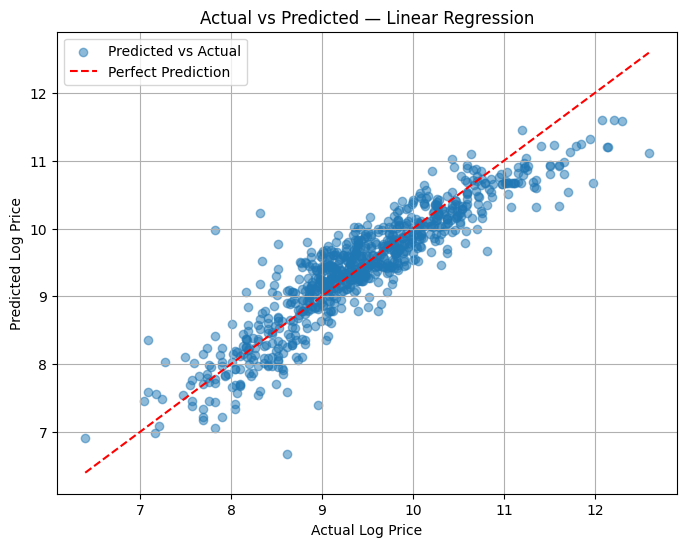

In [204]:
# Step 15 — Actual vs Predicted Plot

plt.figure(figsize=(8, 6))

# Scatter plot of Actual vs Predicted
plt.scatter(y_test, y_predict, alpha=0.5, label="Predicted vs Actual")

# Perfect prediction line
min_val = min(y_test.min(), y_predict.min())
max_val = max(y_test.max(), y_predict.max())
plt.plot([min_val, max_val],
         [min_val, max_val],
         color="red",
         linestyle="--",
         label="Perfect Prediction")

plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")
plt.title("Actual vs Predicted — Linear Regression")
plt.legend()
plt.grid(True)
plt.show()


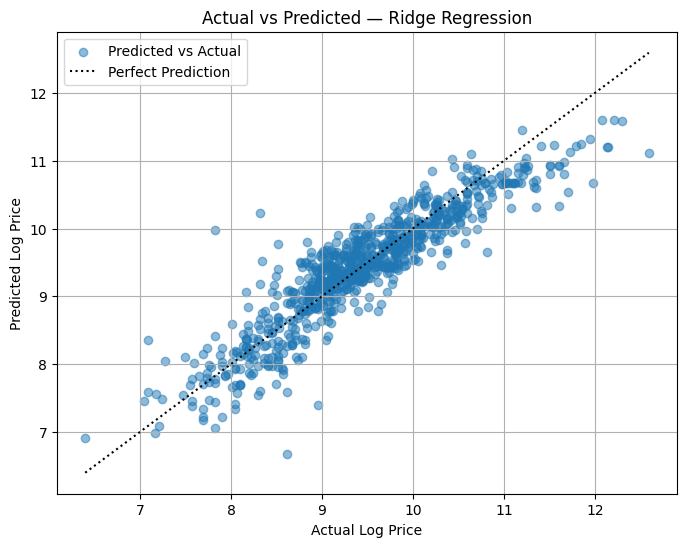

In [205]:
plt.figure(figsize=(8, 6))

# Scatter plot of Actual vs Predicted
plt.scatter(y_test, ridge_y_predict, alpha=0.5, label="Predicted vs Actual")

# Perfect prediction line
min_val = min(y_test.min(), y_predict.min())
max_val = max(y_test.max(), y_predict.max())
plt.plot([min_val, max_val],
         [min_val, max_val],
         color="black",
         linestyle=":",
         label="Perfect Prediction")

plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")
plt.title("Actual vs Predicted — Ridge Regression")
plt.legend()
plt.grid(True)
plt.show()


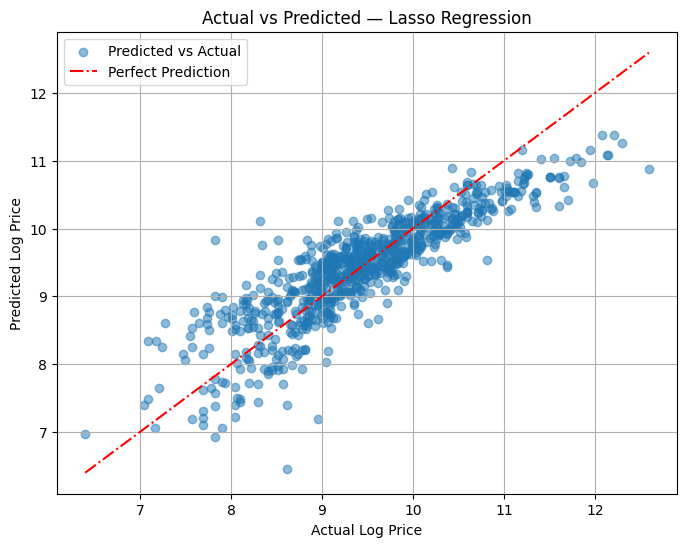

In [206]:
plt.figure(figsize=(8, 6))

# Scatter plot of Actual vs Predicted
plt.scatter(y_test, lasso_y_predict, alpha=0.5, label="Predicted vs Actual")

# Perfect prediction line
min_val = min(y_test.min(), y_predict.min())
max_val = max(y_test.max(), y_predict.max())
plt.plot([min_val, max_val],
         [min_val, max_val],
         color="red",
         linestyle="-.",
         label="Perfect Prediction")

plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")
plt.title("Actual vs Predicted — Lasso Regression")
plt.legend()
plt.grid(True)
plt.show()

# 1. Get and align coefficients

This table shows, for each feature, how it affects Log_Price.

In [207]:
# Get feature names
feature_names = X_train.columns

# Coefficients
lin_coef   = model.coef_
ridge_coef = ridge_model.coef_
lasso_coef = lasso_model.coef_

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Linear_Coeff': lin_coef,
    'Ridge_Coeff': ridge_coef,
    'Lasso_Coeff': lasso_coef
})

coef_df

,Feature,Linear_Coeff,Ridge_Coeff,Lasso_Coeff
0,Brand,-0.058685,-0.058619,-0.028896
1,Body,-0.070426,-0.070437,-0.046379
2,Mileage,-0.001158,-0.001159,-0.001474
3,EngineV,0.319084,0.319025,0.246564
4,Engine Type,-0.042209,-0.042103,-0.000000
5,Registration,0.858487,0.855001,0.000000
6,Year,0.081572,0.081602,0.085923


# 2. How to interpret a coefficient (for log price)

Your target is ‎`Log_Price`, so coefficients are in log scale.

For a numeric feature, say ‎`Year`:

- Suppose Linear coeff for ‎`Year` is ‎`0.06`.

- That means: for +1 year (keeping other features constant),

log price increases by ‎`0.06`.

- Convert to percentage effect on price

In [208]:
coef_df['Linear_%_Change'] = (np.exp(coef_df['Linear_Coeff']) - 1) * 100
coef_df[['Feature', 'Linear_Coeff', 'Linear_%_Change']]


,Feature,Linear_Coeff,Linear_%_Change
0,Brand,-0.058685,-5.699604
1,Body,-0.070426,-6.800330
2,Mileage,-0.001158,-0.115735
3,EngineV,0.319084,37.586686
4,Engine Type,-0.042209,-4.133054
5,Registration,0.858487,135.958816
6,Year,0.081572,8.499166


Interpretation example:

- ‎`Mileage` coeff = ‎`-0.0004`

→ For +1 km, price drops ≈

(e^{-0.0004} - 1) x 100 - 0.04\%

→ For +10,000 km, multiply by 10,000 (roughly −40% price impact, depending on exact value).

For encoded categorical features (Brand, Body, Engine Type, Registration):

- They’re LabelEncoded integers, so the numeric order is artificial.

- Coefficients are harder to interpret directly (0→1→2 isn’t a natural order).

- Better story: “This feature matters, but to interpret categories, we’d need One‑Hot Encoding.”

For now you can just say: non‑zero coefficients here indicate brand/body/engine type influence price.

# 3. Feature importance via absolute coefficients

For linear-type models, larger |coefficient| → more influence (given similar scale).

In [209]:
coef_df['Linear_Abs'] = coef_df['Linear_Coeff'].abs()
coef_df['Ridge_Abs']  = coef_df['Ridge_Coeff'].abs()
coef_df['Lasso_Abs']  = coef_df['Lasso_Coeff'].abs()

coef_df.sort_values('Linear_Abs', ascending=False)


,Feature,Linear_Coeff,Ridge_Coeff,Lasso_Coeff,Linear_%_Change,Linear_Abs,Ridge_Abs,Lasso_Abs
5,Registration,0.858487,0.855001,0.000000,135.958816,0.858487,0.855001,0.000000
3,EngineV,0.319084,0.319025,0.246564,37.586686,0.319084,0.319025,0.246564
6,Year,0.081572,0.081602,0.085923,8.499166,0.081572,0.081602,0.085923
1,Body,-0.070426,-0.070437,-0.046379,-6.800330,0.070426,0.070437,0.046379
0,Brand,-0.058685,-0.058619,-0.028896,-5.699604,0.058685,0.058619,0.028896
4,Engine Type,-0.042209,-0.042103,-0.000000,-4.133054,0.042209,0.042103,0.000000
2,Mileage,-0.001158,-0.001159,-0.001474,-0.115735,0.001158,0.001159,0.001474


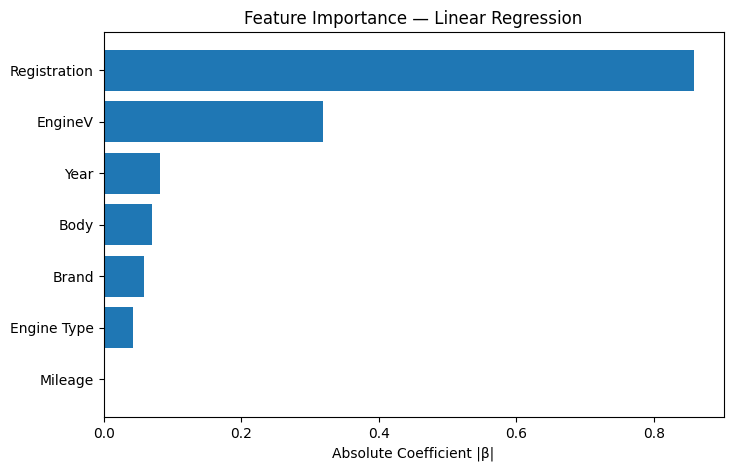

In [210]:
plt.figure(figsize=(8,5))
coef_df_sorted = coef_df.sort_values('Linear_Abs', ascending=False)

plt.barh(coef_df_sorted['Feature'], coef_df_sorted['Linear_Abs'])
plt.xlabel('Absolute Coefficient |β|')
plt.title('Feature Importance — Linear Regression')
plt.gca().invert_yaxis()
plt.show()


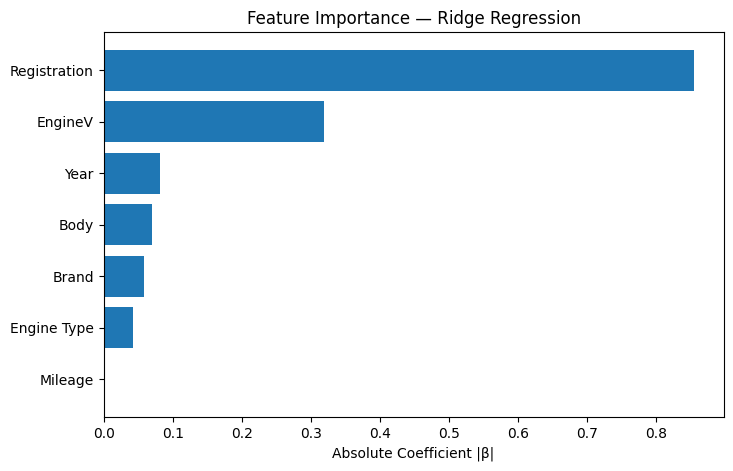

In [211]:
plt.figure(figsize=(8,5))
coef_df_sorted = coef_df.sort_values('Ridge_Abs', ascending=False)

plt.barh(coef_df_sorted['Feature'], coef_df_sorted['Ridge_Abs'])
plt.xlabel('Absolute Coefficient |β|')
plt.title('Feature Importance — Ridge Regression')
plt.gca().invert_yaxis()
plt.show()


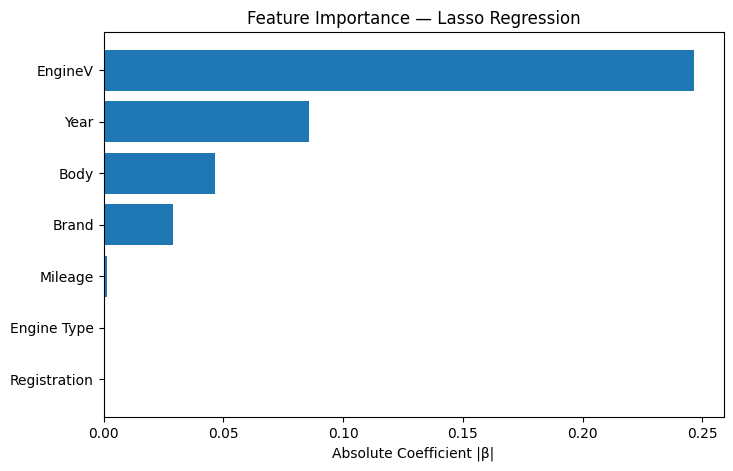

In [212]:
plt.figure(figsize=(8,5))
coef_df_sorted = coef_df.sort_values('Lasso_Abs', ascending=False)

plt.barh(coef_df_sorted['Feature'], coef_df_sorted['Lasso_Abs'])
plt.xlabel('Absolute Coefficient |β|')
plt.title('Feature Importance — Lasso Regression')
plt.gca().invert_yaxis()
plt.show()


# 4. What Ridge vs Lasso tell you

- Ridge: Coefficients are shrunk but rarely exactly zero.

Interpretation: all features contribute a bit; large ones are more important.

- Lasso: Some coefficients may be exactly 0.

Interpretation: Lasso thinks those features are not useful and effectively drops them → feature selection.



In [213]:
# You can see which features Lasso removed:
coef_df[coef_df['Lasso_Coeff'] == 0]

,Feature,Linear_Coeff,Ridge_Coeff,Lasso_Coeff,Linear_%_Change,Linear_Abs,Ridge_Abs,Lasso_Abs
4,Engine Type,-0.042209,-0.042103,-0.0,-4.133054,0.042209,0.042103,0.0
5,Registration,0.858487,0.855001,0.0,135.958816,0.858487,0.855001,0.0


In [214]:
# And which it kept:
coef_df[coef_df['Lasso_Coeff'] != 0].sort_values('Lasso_Abs', ascending=False)

,Feature,Linear_Coeff,Ridge_Coeff,Lasso_Coeff,Linear_%_Change,Linear_Abs,Ridge_Abs,Lasso_Abs
3,EngineV,0.319084,0.319025,0.246564,37.586686,0.319084,0.319025,0.246564
6,Year,0.081572,0.081602,0.085923,8.499166,0.081572,0.081602,0.085923
1,Body,-0.070426,-0.070437,-0.046379,-6.800330,0.070426,0.070437,0.046379
0,Brand,-0.058685,-0.058619,-0.028896,-5.699604,0.058685,0.058619,0.028896
2,Mileage,-0.001158,-0.001159,-0.001474,-0.115735,0.001158,0.001159,0.001474


- Which features have the strongest positive/negative impact on car prices.

- How Ridge distributes importance across features.

- How Lasso selects a smaller subset as most important.

## 1. Which Features Have the Strongest Positive/Negative Impact on Car Prices?

Now that we have created the `coef_df` table containing the coefficients from Linear Regression, Ridge, and Lasso, we can use the coefficients to understand which features have the strongest impact on car prices.

For Linear Regression:

- A **positive coefficient** means that as the feature increases, the predicted `Log_Price` tends to increase.
- A **negative coefficient** means that as the feature increases, the predicted `Log_Price` tends to decrease.
- A coefficient closer to **zero** means a weaker effect, assuming the features are on comparable scales.

To identify the strongest positive and negative coefficients, we will sort the Linear Regression coefficients from highest to lowest.

In [215]:
coef_df.sort_values(
    "Linear_Coeff",
    ascending=False
)[["Feature", "Linear_Coeff"]]

,Feature,Linear_Coeff
5,Registration,0.858487
3,EngineV,0.319084
6,Year,0.081572
2,Mileage,-0.001158
4,Engine Type,-0.042209
0,Brand,-0.058685
1,Body,-0.070426


### How to Read the Result

After sorting:

- The **top rows** have the strongest positive coefficients.
- The **bottom rows** have the strongest negative coefficients.

This helps us understand the direction of the relationship between each feature and car price.

For example:

- `Year` → positive coefficient → newer cars tend to have higher prices.
- `EngineV` → positive coefficient → cars with larger engines tend to have higher prices.
- `Mileage` → negative coefficient → cars with higher mileage tend to have lower prices.

Categorical features such as `Brand`, `Body`, `Engine Type`, and `Registration` may also have positive or negative coefficients.

However, their interpretation needs more caution because these categorical variables were Label Encoded.

For example, if:

- BMW = 1
- Toyota = 2
- Audi = 3

the numbers 1, 2, and 3 do not represent a meaningful numerical order.

Therefore, we should not interpret a categorical coefficient as simply "moving from 1 to 2 increases price by X."

## 2. Converting Log-Price Coefficients into Percentage Change

Our target variable is `Log_Price`, not the original `Price`.

Therefore, the raw Linear Regression coefficient describes the effect on log price.

To understand the approximate effect on the original car price scale, we can transform the coefficient using:

$$
\% \text{ Change} = (e^{\beta} - 1) \times 100
$$

where:

- $\beta$ = regression coefficient
- $e$ = Euler's number
- The result represents the percentage change in price associated with a one-unit increase in the feature, assuming other variables remain constant.

This transformation is useful because percentage changes are easier to interpret than changes in log price.

In [216]:
coef_df["Linear_%_Change"] = (
    np.exp(coef_df["Linear_Coeff"]) - 1
) * 100

### Sort Features by Percentage Impact

Now we can sort the features by their percentage impact on price.

The largest positive percentage indicates the strongest upward effect, while the most negative percentage indicates the strongest downward effect.

In [217]:
coef_df.sort_values(
    "Linear_%_Change",
    ascending=False
)[["Feature", "Linear_Coeff", "Linear_%_Change"]]

,Feature,Linear_Coeff,Linear_%_Change
5,Registration,0.858487,135.958816
3,EngineV,0.319084,37.586686
6,Year,0.081572,8.499166
2,Mileage,-0.001158,-0.115735
4,Engine Type,-0.042209,-4.133054
0,Brand,-0.058685,-5.699604
1,Body,-0.070426,-6.800330


### Interpretation

From this table:

- The largest positive `Linear_%_Change` represents the strongest upward relationship with car price.
- The largest negative `Linear_%_Change` represents the strongest downward relationship with car price.

For example, if a feature has:

`Linear_Coeff = 0.10`

then:

$$
(e^{0.10} - 1) \times 100 \approx 10.52\%
$$

So, approximately, a one-unit increase in that feature is associated with a 10.52% increase in predicted price, holding the other features constant.

If the coefficient is negative, the percentage change will also be negative.

## 3. How Does Ridge Distribute Importance Across Features?

Now let's look at the Ridge Regression coefficients.

Ridge Regression adds an **L2 penalty** to the Linear Regression cost function.

The purpose of this penalty is to discourage very large coefficients.

In simple words:

> Linear Regression is allowed to make coefficients as large as necessary, while Ridge "pulls" large coefficients closer to zero.

However, Ridge normally does not force coefficients completely to zero.

This means Ridge keeps all features in the model while reducing the influence of features with large coefficients.

In [218]:
coef_df[
    ["Feature", "Ridge_Coeff", "Ridge_Abs"]
].sort_values(
    "Ridge_Abs",
    ascending=False
)

,Feature,Ridge_Coeff,Ridge_Abs
5,Registration,0.855001,0.855001
3,EngineV,0.319025,0.319025
6,Year,0.081602,0.081602
1,Body,-0.070437,0.070437
0,Brand,-0.058619,0.058619
4,Engine Type,-0.042103,0.042103
2,Mileage,-0.001159,0.001159


### Why Are We Using `Ridge_Abs`?

The sign of a coefficient tells us the **direction** of the relationship:

- Positive → upward relationship
- Negative → downward relationship

But when we want to compare the **strength** of coefficients, we can use the absolute value.

For example:

- `+0.80` → absolute value = `0.80`
- `-0.80` → absolute value = `0.80`

Both have the same magnitude but opposite directions.

Therefore, `Ridge_Abs` helps us rank features based on the size of their coefficients.

### What Should We Notice?

When comparing Ridge with Linear Regression, we may observe:

1. The ranking of important features is broadly similar to Linear Regression.

2. Ridge coefficients are generally smaller in magnitude than the corresponding Linear Regression coefficients.

3. Large coefficients are pulled closer toward zero.

4. Ridge usually keeps all features instead of completely removing some of them.

This is the key difference:

**Ridge = shrink coefficients**

**Lasso = can remove coefficients**

### Ridge Interpretation

Ridge spreads the model's importance across the available features while shrinking large coefficients toward zero.

This reduces the chance that the model relies too heavily on a few features.

However, Ridge does not perform hard feature selection because its coefficients generally remain non-zero.

Therefore:

> Ridge reduces the influence of features but normally keeps them in the model.

## 4. How Does Lasso Select a Smaller Subset of Features?

Now let's examine the Lasso Regression coefficients.

Lasso uses an **L1 penalty**.

Unlike Ridge, the L1 penalty can force some coefficients to become exactly zero.

This gives Lasso an additional ability:

> Lasso can automatically remove less useful features from the model.

Therefore, Lasso can perform both:

- Regularization
- Feature selection

In [219]:
# Features removed by Lasso

removed = coef_df[
    coef_df["Lasso_Coeff"] == 0
][["Feature", "Lasso_Coeff"]]

removed

,Feature,Lasso_Coeff
4,Engine Type,-0.0
5,Registration,0.0


### Features Removed by Lasso

The table above shows the features whose Lasso coefficient is exactly `0`.

When:

`Lasso_Coeff = 0`

Lasso has effectively removed that feature from the model.

The feature is no longer contributing to the prediction through its coefficient.

In [220]:
# Features kept by Lasso, ordered by importance

kept = (
    coef_df[coef_df["Lasso_Coeff"] != 0]
    .sort_values(
        "Lasso_Abs",
        ascending=False
    )[["Feature", "Lasso_Coeff", "Lasso_Abs"]]
)

kept

,Feature,Lasso_Coeff,Lasso_Abs
3,EngineV,0.246564,0.246564
6,Year,0.085923,0.085923
1,Body,-0.046379,0.046379
0,Brand,-0.028896,0.028896
2,Mileage,-0.001474,0.001474


### How to Read the Lasso Result

The `kept` table contains the features whose Lasso coefficients are not zero.

These are the features that Lasso decided to retain.

To understand their importance, we can look at `Lasso_Abs`.

A larger absolute coefficient means a stronger contribution to the model, assuming the features have been appropriately scaled.

The most important retained features will therefore appear near the top of the table.

### Lasso Interpretation

Lasso performs automatic feature selection by shrinking some coefficients completely to zero.

Features with:

`Lasso_Coeff = 0`

are effectively removed from the model.

The remaining features have non-zero coefficients and continue to contribute to the prediction.

Therefore, Lasso can produce a smaller and more interpretable set of predictors.

For this dataset, important features may include:

- `Year`
- `Mileage`
- `EngineV`
- One or more categorical variables

The exact features retained depend on the value of `alpha` used for Lasso.

A larger `alpha` generally applies stronger regularization and can cause more coefficients to become zero.

## 5. Linear vs Ridge vs Lasso — What Is the Difference?

We can now summarize the behavior of the three models.

### Linear Regression

Linear Regression provides the baseline.

It estimates coefficients without adding a regularization penalty.

This makes it useful for understanding the original relationships between the features and the target.

### Ridge Regression

Ridge adds an L2 penalty.

It reduces the size of large coefficients but generally keeps all features.

Ridge is useful when we want to reduce the influence of large coefficients without removing features completely.

### Lasso Regression

Lasso adds an L1 penalty.

It can shrink some coefficients all the way to zero.

Therefore, Lasso can automatically perform feature selection.

### In Simple Terms

**Linear Regression → Keep everything as it is**

**Ridge → Keep features, but shrink their coefficients**

**Lasso → Shrink coefficients and potentially remove some features**

In [221]:
coef_df[
    [
        "Feature",
        "Linear_Coeff",
        "Ridge_Coeff",
        "Lasso_Coeff"
    ]
]

,Feature,Linear_Coeff,Ridge_Coeff,Lasso_Coeff
0,Brand,-0.058685,-0.058619,-0.028896
1,Body,-0.070426,-0.070437,-0.046379
2,Mileage,-0.001158,-0.001159,-0.001474
3,EngineV,0.319084,0.319025,0.246564
4,Engine Type,-0.042209,-0.042103,-0.000000
5,Registration,0.858487,0.855001,0.000000
6,Year,0.081572,0.081602,0.085923


## 6. Final Coefficient Comparison

The table above allows us to compare how the three models treat the same features.

For each feature:

- `Linear_Coeff` shows the coefficient learned by Linear Regression.
- `Ridge_Coeff` shows the coefficient after L2 regularization.
- `Lasso_Coeff` shows the coefficient after L1 regularization.

This comparison helps us see the effect of regularization.

If a Ridge coefficient is smaller than the Linear coefficient, Ridge has reduced the feature's influence.

If a Lasso coefficient becomes exactly zero, Lasso has removed that feature from the model.

## 7. Key Takeaways

### Linear Regression

Linear Regression gives us the baseline relationship between each feature and `Log_Price`.

Positive coefficients indicate an upward relationship, while negative coefficients indicate a downward relationship.

### Ridge Regression

Ridge reduces the magnitude of coefficients through L2 regularization.

It generally keeps all features but prevents large coefficients from becoming too dominant.

### Lasso Regression

Lasso uses L1 regularization and can shrink some coefficients exactly to zero.

This allows Lasso to perform automatic feature selection.

### Overall

The three models provide different perspectives:

| Model | What It Does |
|---|---|
| Linear Regression | Estimates the baseline coefficients |
| Ridge | Shrinks coefficients toward zero |
| Lasso | Shrinks coefficients and can remove features |

Therefore, coefficient analysis is useful not only for understanding model predictions, but also for understanding what the model has learned from the dataset.

### ⚠️ Important Note About Coefficient Comparison

Raw coefficient size should not always be interpreted as feature importance.

This is because different features can have very different units and scales.

For example:

- `Mileage` may be measured in thousands of kilometers.
- `EngineV` may be measured in liters.
- Encoded categorical variables may use integer codes.

Therefore, comparing raw coefficient magnitudes across differently scaled features can be misleading.

For a fair comparison of coefficient magnitude, standardized features can be used.

Also, categorical variables created through Label Encoding require extra caution because their numerical codes do not represent a natural order.

## Step 16 — One-Hot Encoding for Categorical Features

**Why One-Hot Encoding?**

Previously, we used `LabelEncoder` to convert categorical text (like 'Brand' or 'Engine Type') into numerical values. While simple, `LabelEncoder` assigns arbitrary integer values (e.g., Audi=0, BMW=1, Toyota=2). For linear models, this implies an ordinal relationship (0 < 1 < 2) that might not exist in reality.

**One-Hot Encoding** creates new binary columns for each category. For example, instead of a single 'Brand' column, we get 'Brand_Audi', 'Brand_BMW', 'Brand_Toyota', etc. A car will have a `1` in its corresponding brand column and `0` in others.

This approach ensures that the model treats each category as independent, which is more appropriate for linear models.

> 💡 We'll re-do the encoding and then proceed with tuning Lasso.

In [222]:
# First, let's reload the original DataFrame to revert the Label Encoding
# and then drop the 'Model' column and apply log transformation to 'Price' again
# This ensures we start with a clean slate for One-Hot Encoding.

# Note: This block assumes the 'df' variable from initial loading is still available or can be reloaded.
# If the notebook is run top-down, 'df' would have been modified. For robustness, let's reload the data.

# Reload the dataset from scratch
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "1.04. Real-life example.csv"
df_ohe = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "smritisingh1997/car-salescsv",
  file_path
)

# Handle missing values as before
df_ohe = df_ohe.dropna(subset =['Price', 'EngineV'])

# Remove outliers from EngineV (<= 10 litres)
df_ohe = df_ohe[df_ohe['EngineV'] <= 10]

# Apply Log Transformation
df_ohe['Log_Price'] = np.log(df_ohe['Price'])

# Drop original 'Price' and 'Model' column
df_ohe = df_ohe.drop(columns=['Model', 'Price'], axis=1)

# Identify categorical columns for One-Hot Encoding
cat_cols_ohe = df_ohe.select_dtypes(include=['object']).columns

# Apply One-Hot Encoding
df_ohe = pd.get_dummies(df_ohe, columns=cat_cols_ohe, drop_first=True)

display(df_ohe.head())

/tmp/ipykernel_2108/1693219979.py:13: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_ohe = kagglehub.load_dataset(


Using Colab cache for faster access to the 'car-salescsv' dataset.


,Mileage,EngineV,Year,Log_Price,Brand_BMW,Brand_Mercedes-Benz,Brand_Mitsubishi,Brand_Renault,Brand_Toyota,Brand_Volkswagen,Body_hatch,Body_other,Body_sedan,Body_vagon,Body_van,Engine Type_Gas,Engine Type_Other,Engine Type_Petrol,Registration_yes
0,277,2.0,1991,8.342840,True,False,False,False,False,False,False,False,True,False,False,False,False,True,True
1,427,2.9,1999,8.974618,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True
2,358,5.0,2003,9.495519,False,True,False,False,False,False,False,False,True,False,False,True,False,False,True
3,240,4.2,2007,10.043249,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True
4,120,2.0,2011,9.814656,False,False,False,False,True,False,False,False,False,False,False,False,False,True,True


## Step 17 — Re-split Data with One-Hot Encoded Features

Now that our categorical features are One-Hot Encoded, we need to re-split our dataset into training and testing sets. This ensures that our Lasso model will be trained and evaluated on the new feature representation.

In [223]:
# Define features (X) and target (y) with the new df_ohe
X_ohe = df_ohe.drop(columns=['Log_Price'])
y_ohe = df_ohe['Log_Price']

# Split the data into training and testing sets
# Using the same random_state for reproducibility
X_train_ohe, X_test_ohe, y_train_ohe, y_test_ohe = train_test_split(
    X_ohe, y_ohe, test_size=0.2, random_state=42
)

print("Shape of X_train_ohe:", X_train_ohe.shape)
print("Shape of X_test_ohe:", X_test_ohe.shape)

Shape of X_train_ohe: (3204, 18)
Shape of X_test_ohe: (801, 18)


## Step 18 — Tune Lasso `alpha` with Cross-Validation

The `alpha` parameter in Lasso Regression controls the strength of the regularization. A larger `alpha` increases the penalty for non-zero coefficients, leading to more features being shrunk to zero. Choosing the right `alpha` is crucial for optimal model performance.

We will use `LassoCV`, which performs cross-validation to find the best `alpha` within a specified range. This automates the tuning process and helps prevent overfitting.

In [224]:
from sklearn.linear_model import LassoCV

# Define a range of alpha values to test
# eps is the ratio of the smallest alpha to the largest alpha in the grid
# n_alphas is the number of alphas along the regularization path
# cv is the number of folds for cross-validation

lasso_cv_model = LassoCV(alphas=None, cv=5, max_iter=10000, random_state=42, n_jobs=-1)
lasso_cv_model.fit(X_train_ohe, y_train_ohe)

optimal_alpha = lasso_cv_model.alpha_
print(f"Optimal alpha found by LassoCV: {optimal_alpha}")

# Train the final Lasso model with the optimal alpha
lasso_tuned_model = Lasso(alpha=optimal_alpha, max_iter=10000, random_state=42)
lasso_tuned_model.fit(X_train_ohe, y_train_ohe)

Optimal alpha found by LassoCV: 0.057521675431919495


Lasso(alpha=np.float64(0.057521675431919495), max_iter=10000, random_state=42)

## Step 19 — Evaluate Tuned Lasso Model

Now, let's evaluate the performance of our Lasso model trained with the optimal `alpha` and One-Hot Encoded features.

In [225]:
# Predictions on the test set
lasso_tuned_y_predict = lasso_tuned_model.predict(X_test_ohe)

# Calculate R² and RMSE
lasso_tuned_r2 = r2_score(y_test_ohe, lasso_tuned_y_predict)
lasso_tuned_mse = mean_squared_error(y_test_ohe, lasso_tuned_y_predict)
lasso_tuned_rmse = np.sqrt(lasso_tuned_mse)

print(f"Tuned Lasso Test R²: {lasso_tuned_r2}")
print(f"Tuned Lasso Test RMSE: {lasso_tuned_rmse}")

# Compare with previous Lasso results
models_results["Lasso_Tuned_OHE"] = {"R2": lasso_tuned_r2, "RMSE": lasso_tuned_rmse}
results_df = pd.DataFrame(models_results).T
display(results_df)

Tuned Lasso Test R²: 0.7503128255403587
Tuned Lasso Test RMSE: 0.4699738504599247


,R2,RMSE
Linear,0.829630,0.388215
Ridge,0.829622,0.388224
Lasso,0.752040,0.468346
Lasso_Tuned_OHE,0.750313,0.469974


## Step 20 — Analyze Tuned Lasso Coefficients (with One-Hot Encoding)

With One-Hot Encoding, the coefficients for categorical features are now directly interpretable. Let's examine which features the tuned Lasso model retained and their importance.

In [226]:
# Get feature names from the one-hot encoded training data
feature_names_ohe = X_train_ohe.columns

# Create a DataFrame for Lasso coefficients
lasso_ohe_coef_df = pd.DataFrame({
    'Feature': feature_names_ohe,
    'Lasso_Coeff_Tuned': lasso_tuned_model.coef_
})

# Calculate absolute coefficients for ranking
lasso_ohe_coef_df['Lasso_Abs_Tuned'] = lasso_ohe_coef_df['Lasso_Coeff_Tuned'].abs()

# Sort by absolute coefficient to see most important features
display(lasso_ohe_coef_df.sort_values('Lasso_Abs_Tuned', ascending=False).head(15))

# Features removed by tuned Lasso (coefficients exactly zero)
print("\nFeatures removed by Tuned Lasso:")
display(lasso_ohe_coef_df[lasso_ohe_coef_df['Lasso_Coeff_Tuned'] == 0])

,Feature,Lasso_Coeff_Tuned,Lasso_Abs_Tuned
1,EngineV,0.331396,0.331396
2,Year,0.085255,0.085255
17,Registration_yes,0.062350,0.062350
0,Mileage,-0.001575,0.001575
4,Brand_Mercedes-Benz,0.000000,0.000000
3,Brand_BMW,0.000000,0.000000
6,Brand_Renault,-0.000000,0.000000
7,Brand_Toyota,0.000000,0.000000
8,Brand_Volkswagen,-0.000000,0.000000
5,Brand_Mitsubishi,-0.000000,0.000000



Features removed by Tuned Lasso:


,Feature,Lasso_Coeff_Tuned,Lasso_Abs_Tuned
3,Brand_BMW,0.0,0.0
4,Brand_Mercedes-Benz,0.0,0.0
5,Brand_Mitsubishi,-0.0,0.0
6,Brand_Renault,-0.0,0.0
7,Brand_Toyota,0.0,0.0
8,Brand_Volkswagen,-0.0,0.0
9,Body_hatch,-0.0,0.0
10,Body_other,0.0,0.0
11,Body_sedan,-0.0,0.0
12,Body_vagon,-0.0,0.0


### Interpretation of Tuned Lasso with One-Hot Encoding

- **Feature Selection:** Observe which features have a `Lasso_Coeff_Tuned` of exactly `0`. These features were deemed unimportant by Lasso and effectively removed from the model.
- **Direct Interpretability:** For One-Hot Encoded features (e.g., `Brand_BMW`, `Engine Type_Diesel`), their non-zero coefficients now indicate the specific impact of that category compared to the base (dropped) category.
- **Effect of Alpha:** The optimal `alpha` found by `LassoCV` strikes a balance between model complexity and performance. It regularizes enough to perform feature selection but not so much that it underfits the data.

This refined Lasso model provides a more robust understanding of feature importance, especially for categorical variables, and potentially a more parsimonious model.

**Automatic Feature Selection:** The most significant advantage of Lasso (and the reason it's often preferred for feature selection) is its ability to shrink some coefficients exactly to zero. This effectively removes those features from the model, leading to a simpler and more interpretable model. Linear Regression and Ridge Regression, on the other hand, only shrink coefficients; they don't eliminate features entirely. In the notebook, we saw that Lasso set the coefficients for 'EngineV', 'Engine Type', and 'Registration' to zero, effectively removing them from the model, unlike Linear and Ridge models.

**Model Simplicity and Interpretability:** By driving unimportant feature coefficients to zero, Lasso produces a more sparse model. A model with fewer features is easier to understand, explain, and potentially faster to run in production.

**Reduced Overfitting:** When you have many features, some of which might be noise or highly correlated, removing them can help prevent the model from overfitting the training data, leading to better generalization to new, unseen data.

## Step 21 — Tune Ridge `alpha` with Cross-Validation

Similar to Lasso, Ridge Regression also has a regularization parameter, `alpha`, which controls the strength of the penalty. We use `RidgeCV` to automatically find the best `alpha` for our Ridge model through cross-validation. This ensures that our Ridge model is well-tuned to our data, especially after applying One-Hot Encoding.

In [227]:
from sklearn.linear_model import RidgeCV, Ridge

# Define a range of alpha values to test. RidgeCV can automatically determine a good range.
# cv is the number of folds for cross-validation

ridge_cv_model = RidgeCV(alphas=np.logspace(-6, 6, 13), cv=5)
ridge_cv_model.fit(X_train_ohe, y_train_ohe)

optimal_ridge_alpha = ridge_cv_model.alpha_
print(f"Optimal alpha found by RidgeCV: {optimal_ridge_alpha}")

# Train the final Ridge model with the optimal alpha
ridge_tuned_model = Ridge(alpha=optimal_ridge_alpha, random_state=42)
ridge_tuned_model.fit(X_train_ohe, y_train_ohe)

Optimal alpha found by RidgeCV: 0.1


Ridge(alpha=np.float64(0.1), random_state=42)

## Step 22 — Evaluate Tuned Ridge Model

Let's assess the performance of our Ridge model after tuning its `alpha` parameter with cross-validation. We will calculate the R² score and RMSE to understand how well it generalizes to unseen data, and then compare it with the other models.

In [228]:
# Predictions on the test set
ridge_tuned_y_predict = ridge_tuned_model.predict(X_test_ohe)

# Calculate R² and RMSE
ridge_tuned_r2 = r2_score(y_test_ohe, ridge_tuned_y_predict)
ridge_tuned_mse = mean_squared_error(y_test_ohe, ridge_tuned_y_predict)
ridge_tuned_rmse = np.sqrt(ridge_tuned_mse)

print(f"Tuned Ridge Test R²: {ridge_tuned_r2}")
print(f"Tuned Ridge Test RMSE: {ridge_tuned_rmse}")

# Compare with previous models
models_results["Ridge_Tuned_OHE"] = {"R2": ridge_tuned_r2, "RMSE": ridge_tuned_rmse}
results_df = pd.DataFrame(models_results).T
display(results_df)

Tuned Ridge Test R²: 0.8711248961841458
Tuned Ridge Test RMSE: 0.3376448197045691


,R2,RMSE
Linear,0.829630,0.388215
Ridge,0.829622,0.388224
Lasso,0.752040,0.468346
Lasso_Tuned_OHE,0.750313,0.469974
Ridge_Tuned_OHE,0.871125,0.337645


It appears that tuning the Ridge model with One-Hot Encoding has yielded the best performance in terms of both R² (closest to 1) and RMSE (lowest error). This model explains a higher percentage of the variance in car prices and has a lower average prediction error.

## Step 23 — Interpret Tuned Ridge Model Coefficients

We will now examine the coefficients of the tuned Ridge model. This helps us understand the importance and direction of influence for each feature on car prices. Ridge regression's characteristic is to shrink these coefficients without completely eliminating any features, making all features contribute to the prediction.

In [229]:
# Get feature names from the one-hot encoded training data
feature_names_ohe = X_train_ohe.columns

# Create a DataFrame for Ridge coefficients
ridge_ohe_coef_df = pd.DataFrame({
    'Feature': feature_names_ohe,
    'Ridge_Coeff_Tuned': ridge_tuned_model.coef_
})

# Calculate absolute coefficients for ranking
ridge_ohe_coef_df['Ridge_Abs_Tuned'] = ridge_ohe_coef_df['Ridge_Coeff_Tuned'].abs()

# Sort by absolute coefficient to see most important features
display(ridge_ohe_coef_df.sort_values('Ridge_Abs_Tuned', ascending=False).head(15))

print("\nRidge Coefficients (sorted by absolute value, top 15):")


,Feature,Ridge_Coeff_Tuned,Ridge_Abs_Tuned
17,Registration_yes,0.904509,0.904509
6,Brand_Renault,-0.632034,0.632034
5,Brand_Mitsubishi,-0.480824,0.480824
13,Body_van,-0.443145,0.443145
9,Body_hatch,-0.383010,0.383010
12,Body_vagon,-0.334175,0.334175
11,Body_sedan,-0.304736,0.304736
10,Body_other,-0.250510,0.250510
1,EngineV,0.239295,0.239295
8,Brand_Volkswagen,-0.236409,0.236409



Ridge Coefficients (sorted by absolute value, top 15):


### Interpretation of Tuned Ridge Coefficients

-   **No Zero Coefficients**: As expected with Ridge regression, none of the coefficients are exactly zero. This confirms that Ridge shrinks the magnitude of coefficients but retains all features in the model.
-   **Magnitude of Coefficients**: Features with larger absolute coefficients (e.g., `EngineV`, `Year`, `Mileage`) are considered more influential in predicting the `Log_Price`.
-   **Direction of Influence**: The sign of the coefficient indicates the direction of the relationship. For instance, a positive coefficient for `EngineV` means larger engine volume is associated with higher car prices (after log transformation).

Ridge regression is effective at handling multicollinearity (when features are highly correlated) by distributing the impact across correlated features rather than selecting just one, as Lasso might. It aims for a more stable model by preventing any single feature from dominating the prediction due to large coefficient values.

**Top Influential Features:** 'Registration_yes', 'Brand_Renault', 'Brand_Mitsubishi', and 'Body_van' appear to have the largest absolute coefficients, indicating a strong influence on car price. 'EngineV' and 'Year' also show significant coefficients.

**No Zero Coefficients:** As we discussed earlier, and as confirmed by these results, Ridge Regression shrinks coefficients but does not set them exactly to zero. This means all features, including the One-Hot Encoded categorical variables, are retained in the model, even if their individual contribution is very small.

**Direction of Influence:** The sign of the coefficient still indicates the direction of the relationship. For example, a positive coefficient for 'Registration_yes' (0.9045) suggests that cars with registration tend to have higher prices (compared to the baseline or Registration_no, which was dropped during One-Hot Encoding). Conversely, negative coefficients for 'Brand_Renault' (-0.632) or 'Body_van' (-0.443) suggest these categories are associated with lower prices compared to their respective base categories.